In [7]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'AppleGothic', 'Malgun Gothic', 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

url = "http://apis.data.go.kr/5690000/sjPublicIns/sj_00000110"

params = {
    "serviceKey": "73e6daec9a5083347313b30d8b9d78f83ff022356cffe4f6710361a8d4e7f5ea",
    "pageIndex": 1,
    "pageUnit": 100,
    "dataTy": "json"
}

response = requests.get(url, params=params)

print(response.status_code)
print(response.text[:1000])

200
{"header":{"resultCode":"00","resultMsg":"NORMAL SERVICE","totalCount":41,"pageIndex":1,"pageUnit":100,"searchCondition":"","searchKeyword":""},"body":{"items":[{"publicInstNm":"세종특별자치시청","roadNmAddr":"세종특별자치시 한누리대로 2130","addr":"세종특별자치시 보람동 663","la":36.4800579900,"lo":127.2890394000,"telno":"044-300-3114","hmpg":"https://www.sejong.go.kr/index.jsp"},{"publicInstNm":"세종특별자치시의회","roadNmAddr":"세종특별자치시 한누리대로 2120","addr":"세종특별자치시 보람동 625-6","la":36.4800210400,"lo":127.2904510000,"telno":"044-300-7000","hmpg":"https://council.sejong.go.kr/"},{"publicInstNm":"보건소","roadNmAddr":"세종특별자치시 조치원읍 대첩로 32","addr":"세종특별자치시 조치원읍 신흥리 53-1","la":36.5959704000,"lo":127.2926766000,"telno":"044-301-2000","hmpg":"https://www.sejong.go.kr/health.do"},{"publicInstNm":"농업기술센터","roadNmAddr":"세종특별자치시 연서면 월하천로 289","addr":"세종특별자치시 연서면 쌍전리 16","la":36.5729994300,"lo":127.2831882000,"telno":"044-301-2500","hmpg":"https://www.sejong.go.kr/adtc.do"},{"publicInstNm":"시설관리사업소","roadNmAddr":"세종특별자치시 전동면 심동로 354","

In [8]:
data = response.json()

items = data["body"]["items"]

df = pd.DataFrame(items)

df

,publicInstNm,roadNmAddr,addr,la,lo,telno,hmpg
0,세종특별자치시청,세종특별자치시 한누리대로 2130,세종특별자치시 보람동 663,36.480058,127.289039,044-300-3114,https://www.sejong.go.kr/index.jsp
1,세종특별자치시의회,세종특별자치시 한누리대로 2120,세종특별자치시 보람동 625-6,36.480021,127.290451,044-300-7000,https://council.sejong.go.kr/
2,보건소,세종특별자치시 조치원읍 대첩로 32,세종특별자치시 조치원읍 신흥리 53-1,36.595970,127.292677,044-301-2000,https://www.sejong.go.kr/health.do
3,농업기술센터,세종특별자치시 연서면 월하천로 289,세종특별자치시 연서면 쌍전리 16,36.572999,127.283188,044-301-2500,https://www.sejong.go.kr/adtc.do
4,시설관리사업소,세종특별자치시 전동면 심동로 354,세종특별자치시 전동면 심중리 82,36.670859,127.300290,044-301-3500,https://www.sejong.go.kr/facility.do
5,조치원읍행정복지센터,세종특별자치시 조치원읍 새내16길 17,세종특별자치시 조치원읍 교리 9-1,36.604548,127.298460,044-301-5000,https://www.sejong.go.kr/jochiwon/index.do
6,연기면사무소,세종특별자치시 연기면 당산로 81,세종특별자치시 연기면 한별리 317-34,36.541827,127.273531,044-301-5200,https://www.sejong.go.kr/yeongi/index.do
7,연동면사무소,세종특별자치시 연동면 장욱진로 7,세종특별자치시 연동면 내판리 33-1,36.555336,127.327369,044-301-5300,https://www.sejong.go.kr/yeondong/index.do
8,부강면행정복지센터,세종특별자치시 부강면 부강5길 38,세종특별자치시 부강면 부강리 138,36.529426,127.370753,044-301-5400,https://www.sejong.go.kr/bukang/index.do
9,금남면행정복지센터,세종특별자치시 금남면 용포로 57,세종특별자치시 금남면 용포리 122-1,36.463737,127.280287,044-301-5500,https://www.sejong.go.kr/gumnam/index.do


In [9]:
region_map = {
    '한솔': '한솔동',
    '새롬': '새롬동',
    '나성': '나성동',
    '다정': '다정동',
    '도담': '도담동',
    '어진': '어진동',
    '해밀': '해밀동',
    '아름': '아름동',
    '종촌': '종촌동',
    '고운': '고운동',
    '보람': '보람동',
    '대평': '대평동',
    '소담': '소담동',
    '반곡': '반곡동',
    '가람': '가람동',
    
    
    '산울': '산울동',
    '집현': '집현동',
    '세종': '세종동',
    '한별': '한별동',

    '조치원': '조치원읍',

    '연기': '연기면',
    '연동': '연동면',
    '부강': '부강면',
    '금남': '금남면',
    '장군': '장군면',
    '연서': '연서면',
    '전의': '전의면',
    '전동': '전동면',
    '소정': '소정면'
}

In [10]:
def classify_region(place):
    place = str(place)

    for keyword, region in region_map.items():
        if keyword in place:
            return region

    return '미분류'

In [11]:
df['행정구역'] = df['addr'].apply(classify_region)


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

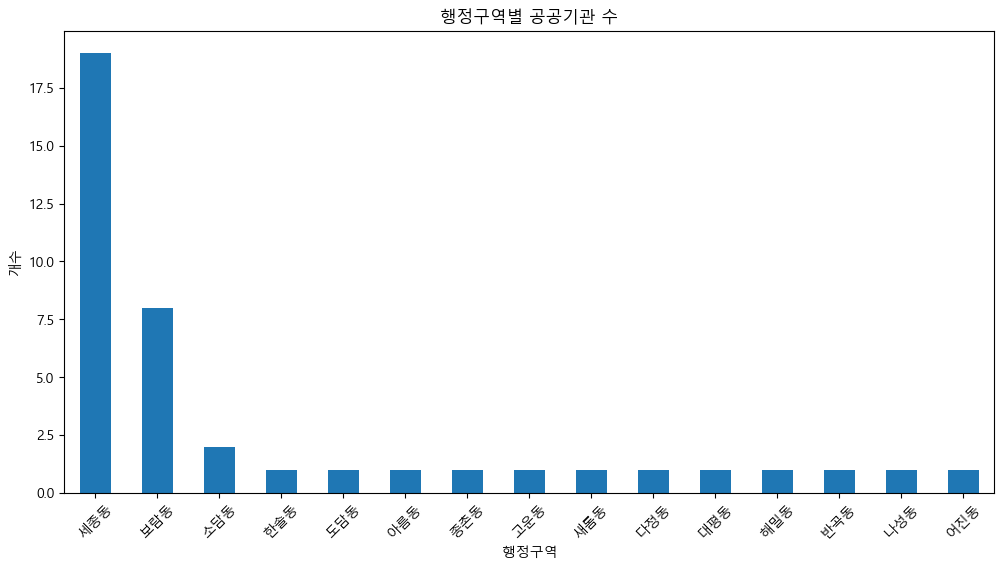

In [12]:

count_df = df['행정구역'].value_counts()

plt.figure(figsize=(12, 6))
count_df.plot(kind='bar')

plt.title('행정구역별 공공기관 수')
plt.xlabel('행정구역')
plt.ylabel('개수')
plt.xticks(rotation=45)
plt.show()